# Снижение размерности сенсорных данных (PCA)

**Датасет:** [Human Activity Recognition](https://www.kaggle.com/datasets/uciml/human-activity-recognition-with-smartphones) - 10299 записей с акселерометра и гироскопа смартфона, 561 признак, 6 видов активности

**Задача:** снизить размерность с 561 признака, сохранив качество классификации активности

## 1. Краткая теория

**PCA** проецирует данные на ортогональные оси максимальной дисперсии (главные компоненты) через собственное разложение ковариационной матрицы. Каждая компонента - линейная комбинация исходных признаков.

Формально: для центрированной матрицы $\mathbf{X} \in \mathbb{R}^{n \times p}$ решается задача $\Sigma \mathbf{v}_k = \lambda_k \mathbf{v}_k$, где $\Sigma = \frac{1}{n-1} \mathbf{X}^T \mathbf{X}$ - ковариационная матрица. Проекция на $d$ компонент: $\mathbf{Z} = \mathbf{X} \mathbf{V}_d$, где $\mathbf{V}_d = [\mathbf{v}_1 | \ldots | \mathbf{v}_d]$.

Доля объяснённой дисперсии $k$-й компоненты: $\frac{\lambda_k}{\sum_{i=1}^{p} \lambda_i}$. Стандартизация обязательна перед PCA. Подробная теория - в [README.md](README.md).

## 2. Загрузка данных

In [1]:
!pip install -q kagglehub

In [2]:
import kagglehub
import os

path = kagglehub.dataset_download("uciml/human-activity-recognition-with-smartphones")
print("Папка:", path)
print("Содержимое:", os.listdir(path))

Папка: C:\Users\danii\.cache\kagglehub\datasets\uciml\human-activity-recognition-with-smartphones\versions\2
Содержимое: ['test.csv', 'train.csv']


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# загрузка train и test
df_train = pd.read_csv(os.path.join(path, 'train.csv'))
df_test = pd.read_csv(os.path.join(path, 'test.csv'))

# разделение на признаки и целевую переменную
X_train = df_train.drop(columns=['subject', 'Activity'])
y_train = df_train['Activity']
X_test = df_test.drop(columns=['subject', 'Activity'])
y_test = df_test['Activity']

feature_names = X_train.columns.tolist()

# перевод названий активностей
activity_names_ru = {
    'WALKING': 'ходьба', 'WALKING_UPSTAIRS': 'подъём по лестнице',
    'WALKING_DOWNSTAIRS': 'спуск по лестнице', 'SITTING': 'сидение',
    'STANDING': 'стояние', 'LAYING': 'лежание'
}

y_train_names = y_train.map(activity_names_ru)
y_test_names = y_test.map(activity_names_ru)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Признаков: {X_train.shape[1]}")
print(f"Классы: {list(activity_names_ru.values())}")

Train: (7352, 561), Test: (2947, 561)
Признаков: 561
Классы: ['ходьба', 'подъём по лестнице', 'спуск по лестнице', 'сидение', 'стояние', 'лежание']


In [4]:
X_train.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


## 3. Первичный анализ

In [5]:
X_train.describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
count,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,...,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000
mean,0.274488,-0.017695,-0.109141,-0.605438,-0.510938,-0.604754,-0.630512,-0.526907,-0.606150,-0.468604,...,0.125293,-0.307009,-0.625294,0.008684,0.002186,0.008726,-0.005981,-0.489547,0.058593,-0.056515
std,0.070261,0.040811,0.056635,0.448734,0.502645,0.418687,0.424073,0.485942,0.414122,0.544547,...,0.250994,0.321011,0.307584,0.336787,0.448306,0.608303,0.477975,0.511807,0.297480,0.279122
min,-1.000000,-1.000000,-1.000000,-1.000000,-0.999873,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-0.995357,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,0.262975,-0.024863,-0.120993,-0.992754,-0.978129,-0.980233,-0.993591,-0.978162,-0.980251,-0.936219,...,-0.023692,-0.542602,-0.845573,-0.121527,-0.289549,-0.482273,-0.376341,-0.812065,-0.017885,-0.143414
50%,0.277193,-0.017219,-0.108676,-0.946196,-0.851897,-0.859365,-0.950709,-0.857328,-0.857143,-0.881637,...,0.134000,-0.343685,-0.711692,0.009509,0.008943,0.008735,-0.000368,-0.709417,0.182071,0.003181
75%,0.288461,-0.010783,-0.097794,-0.242813,-0.034231,-0.262415,-0.292680,-0.066701,-0.265671,-0.017129,...,0.289096,-0.126979,-0.503878,0.150865,0.292861,0.506187,0.359368,-0.509079,0.248353,0.107659
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.946700,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,1.000000,0.478157,1.000000


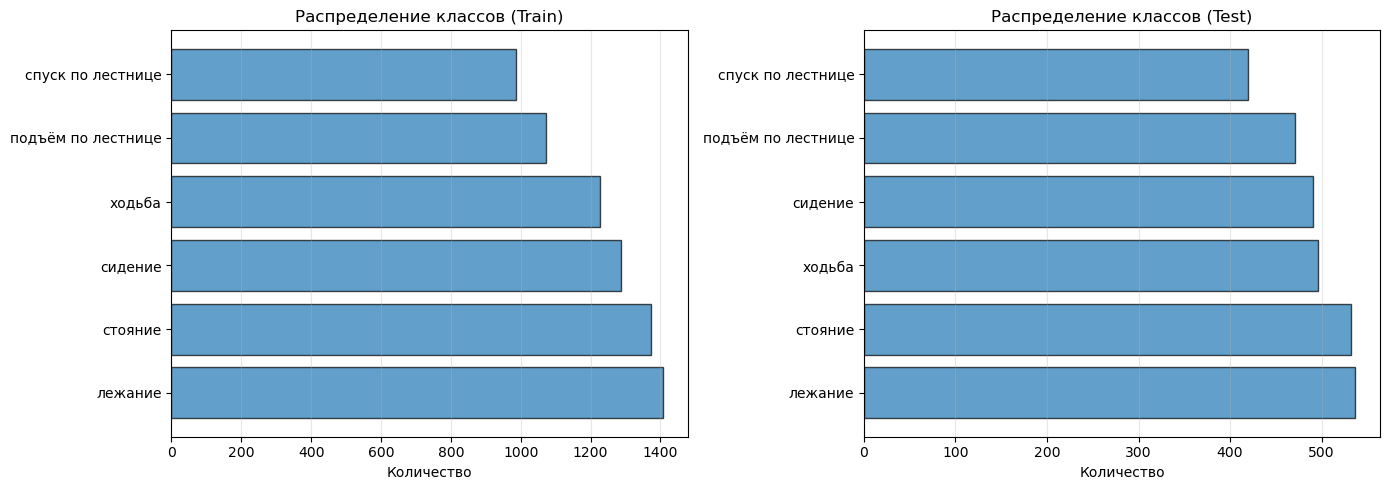

In [6]:
# распределение классов
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (y_names, title) in zip(axes, [(y_train_names, 'Train'), (y_test_names, 'Test')]):
    counts = y_names.value_counts()
    ax.barh(counts.index, counts.values, edgecolor='black', alpha=0.7)
    ax.set_xlabel('Количество')
    ax.set_title(f'Распределение классов ({title})')
    ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

Классы приблизительно сбалансированы в обеих выборках. Динамические активности (ходьба, подъём, спуск) и статические (сидение, стояние, лежание) представлены примерно поровну.

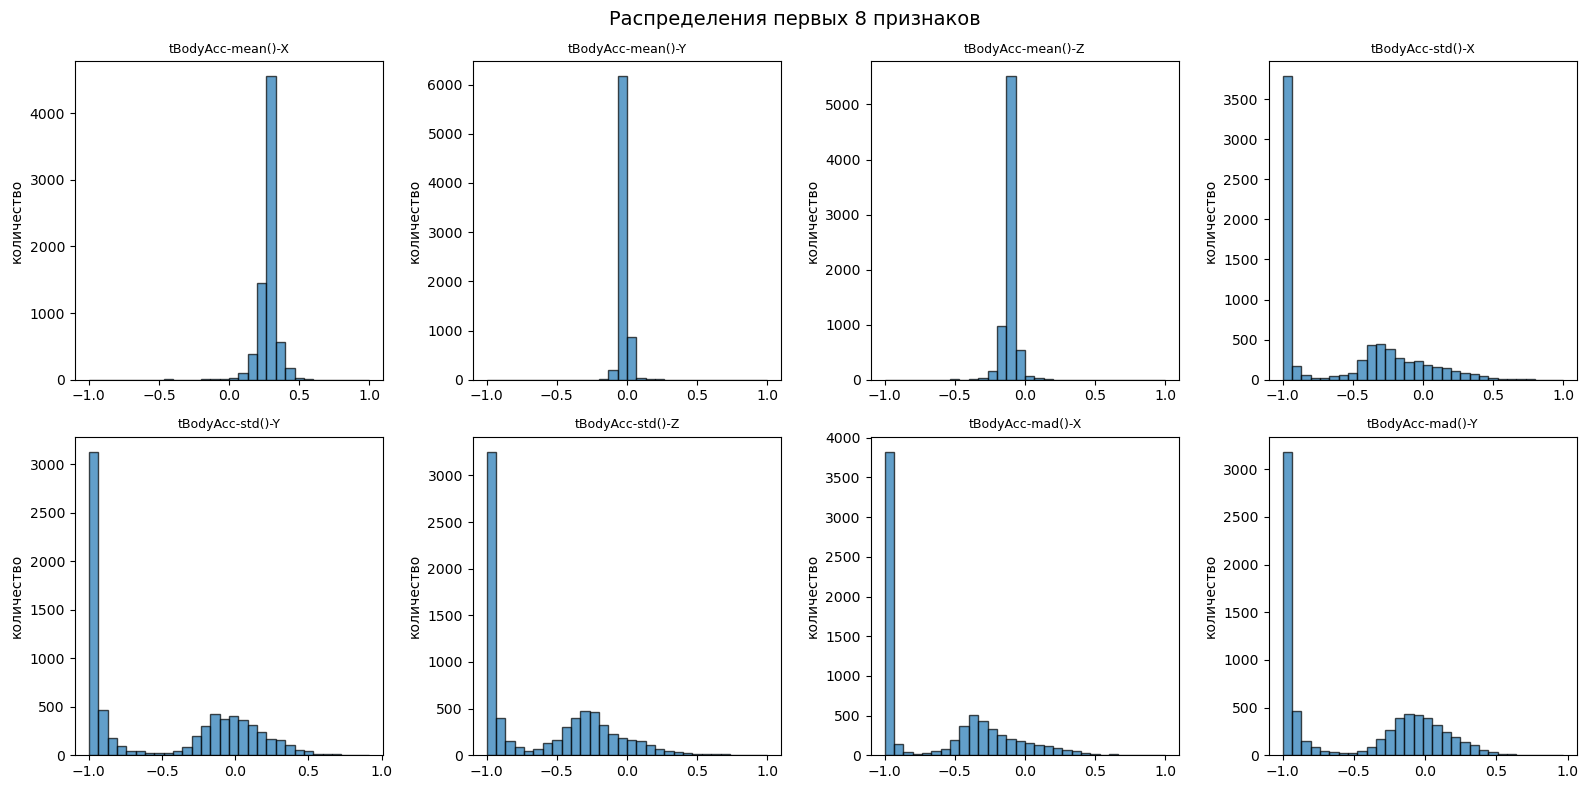

In [7]:
# распределения первых 8 признаков для понимания масштаба
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(8):
    ax = axes[i // 4][i % 4]
    ax.hist(X_train.iloc[:, i], bins=30, edgecolor='black', alpha=0.7)
    name = feature_names[i] if i < len(feature_names) else f'признак {i}'
    ax.set_title(name, fontsize=9)
    ax.set_ylabel('количество')

plt.suptitle('Распределения первых 8 признаков', fontsize=14)
plt.tight_layout()
plt.show()

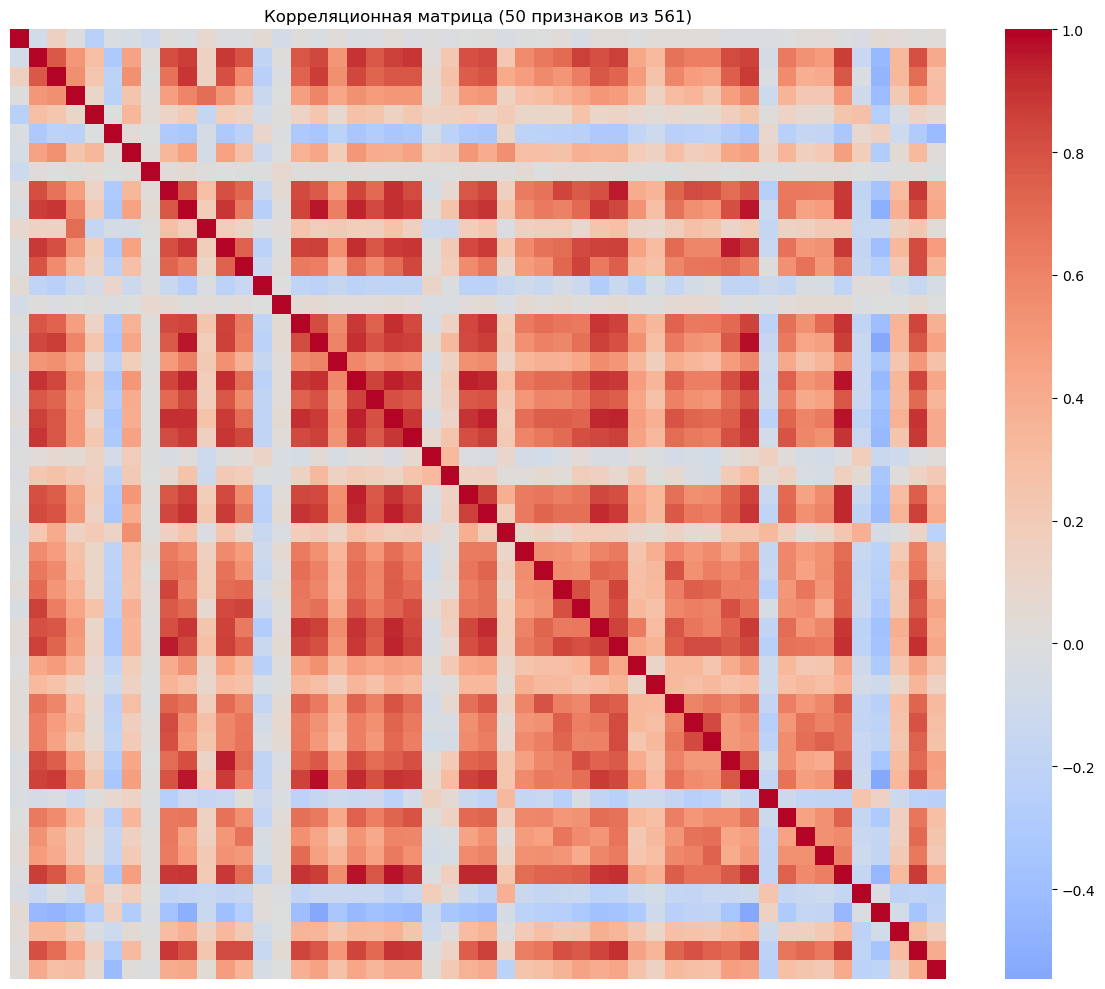

In [8]:
# корреляционная матрица (подвыборка 50 признаков для читаемости)
sample_cols = np.linspace(0, X_train.shape[1] - 1, 50, dtype=int)
corr = X_train.iloc[:, sample_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, xticklabels=False, yticklabels=False)
plt.title('Корреляционная матрица (50 признаков из 561)')
plt.tight_layout()
plt.show()

Видны крупные блоки высокой корреляции - многие из 561 признака сильно связаны между собой. Это типично для сенсорных данных, где разные статистики вычислены по одним и тем же сигналам. PCA эффективно устранит эту избыточность.

In [9]:
# пропуски и дубликаты
print(f"Пропуски в train: {X_train.isnull().sum().sum()}")
print(f"Пропуски в test: {X_test.isnull().sum().sum()}")
print(f"Дубликаты в train: {X_train.duplicated().sum()}")

Пропуски в train: 0
Пропуски в test: 0
Дубликаты в train: 0


## 4. Предобработка

In [10]:
# стандартизация
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f"Train (стандартизованный): среднее={X_train_sc.mean():.6f}, стд={X_train_sc.std():.4f}")
print(f"Размер train: {X_train_sc.shape}, test: {X_test_sc.shape}")

Train (стандартизованный): среднее=0.000000, стд=1.0000
Размер train: (7352, 561), test: (2947, 561)


Данные уже чистые (нет пропусков и дубликатов), разбиение на train/test предоставлено авторами датасета. Выполнена стандартизация - обязательный шаг перед PCA, чтобы все признаки вносили равный вклад.

## 5. Применение PCA

### Baseline - классификация без PCA (SVM на всех 561 признаках)

In [11]:
svm_full = SVC(kernel='rbf', random_state=42)
svm_full.fit(X_train_sc, y_train)
y_pred_full = svm_full.predict(X_test_sc)
acc_full = accuracy_score(y_test, y_pred_full)

print(f"SVM на всех 561 признаках: Accuracy = {acc_full:.4f}")

SVM на всех 561 признаках: Accuracy = 0.9518


### Анализ объяснённой дисперсии

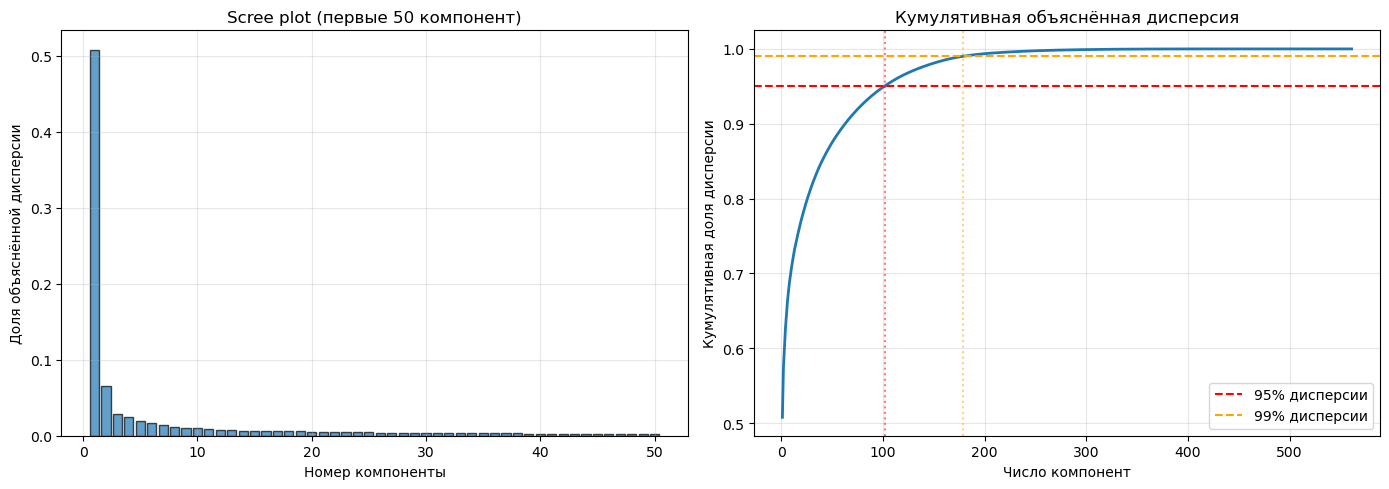

Компонент для 95% дисперсии: 102 из 561
Компонент для 99% дисперсии: 179 из 561
Первая компонента объясняет: 0.5078
Первые 10 компонент объясняют: 0.7082


In [12]:
# PCA на все компоненты для анализа дисперсии
pca_full = PCA(random_state=42)
pca_full.fit(X_train_sc)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# scree plot
axes[0].bar(range(1, 51), explained[:50], alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Номер компоненты')
axes[0].set_ylabel('Доля объяснённой дисперсии')
axes[0].set_title('Scree plot (первые 50 компонент)')
axes[0].grid(True, alpha=0.3)

# кумулятивная дисперсия
axes[1].plot(range(1, len(cumulative) + 1), cumulative, linewidth=2)
axes[1].axhline(y=0.95, color='red', linestyle='--', label='95% дисперсии')
axes[1].axhline(y=0.99, color='orange', linestyle='--', label='99% дисперсии')
n95 = np.argmax(cumulative >= 0.95) + 1
n99 = np.argmax(cumulative >= 0.99) + 1
axes[1].axvline(x=n95, color='red', linestyle=':', alpha=0.5)
axes[1].axvline(x=n99, color='orange', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Число компонент')
axes[1].set_ylabel('Кумулятивная доля дисперсии')
axes[1].set_title('Кумулятивная объяснённая дисперсия')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Компонент для 95% дисперсии: {n95} из 561")
print(f"Компонент для 99% дисперсии: {n99} из 561")
print(f"Первая компонента объясняет: {explained[0]:.4f}")
print(f"Первые 10 компонент объясняют: {cumulative[9]:.4f}")

Первая компонента объясняет 50.78% дисперсии, первые 10 - 70.82%. Для порога 95% достаточно 102 компонент из 561, для 99% - 179. Это подтверждает высокую избыточность признаков: более 80% компонент можно отбросить.

### Визуализация в 2D

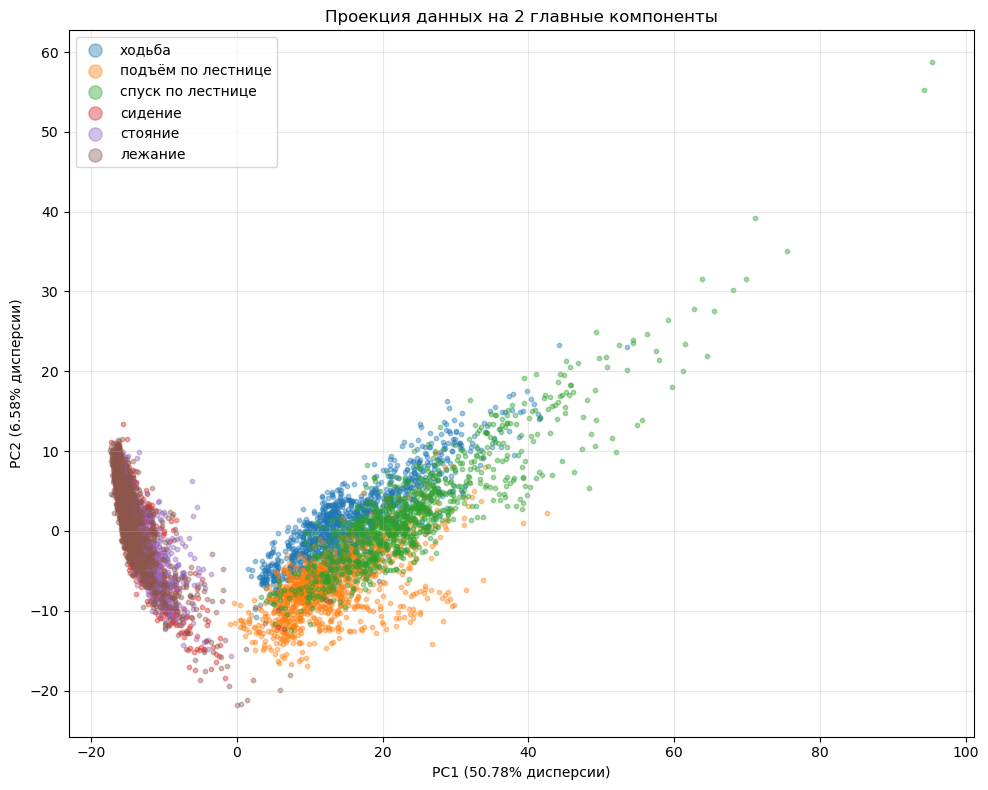

In [13]:
# проекция на 2 компоненты
pca_2d = PCA(n_components=2, random_state=42)
X_train_2d = pca_2d.fit_transform(X_train_sc)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
activity_labels = list(activity_names_ru.values())

plt.figure(figsize=(10, 8))
for i, (label, color) in enumerate(zip(activity_labels, colors)):
    mask = y_train_names == label
    plt.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1],
                c=color, label=label, alpha=0.4, s=10)

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} дисперсии)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} дисперсии)')
plt.title('Проекция данных на 2 главные компоненты')
plt.legend(markerscale=3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Уже в 2D видно разделение на динамические (ходьба, подъём, спуск - левая часть) и статические (сидение, стояние, лежание - правая часть) активности. Сидение и стояние частично перекрываются, что ожидаемо - сенсорные сигналы этих поз похожи.

## 6. Оценка качества

### Accuracy в зависимости от числа компонент

n_components=  2, accuracy=0.5789, дисперсия=0.5736


n_components=  5, accuracy=0.8029, дисперсия=0.6456


n_components= 10, accuracy=0.8456, дисперсия=0.7082


n_components= 20, accuracy=0.8758, дисперсия=0.7737


n_components= 50, accuracy=0.9152, дисперсия=0.8752


n_components=100, accuracy=0.9365, дисперсия=0.9489


n_components=150, accuracy=0.9437, дисперсия=0.9811


n_components=200, accuracy=0.9488, дисперсия=0.9936


n_components=300, accuracy=0.9518, дисперсия=0.9991


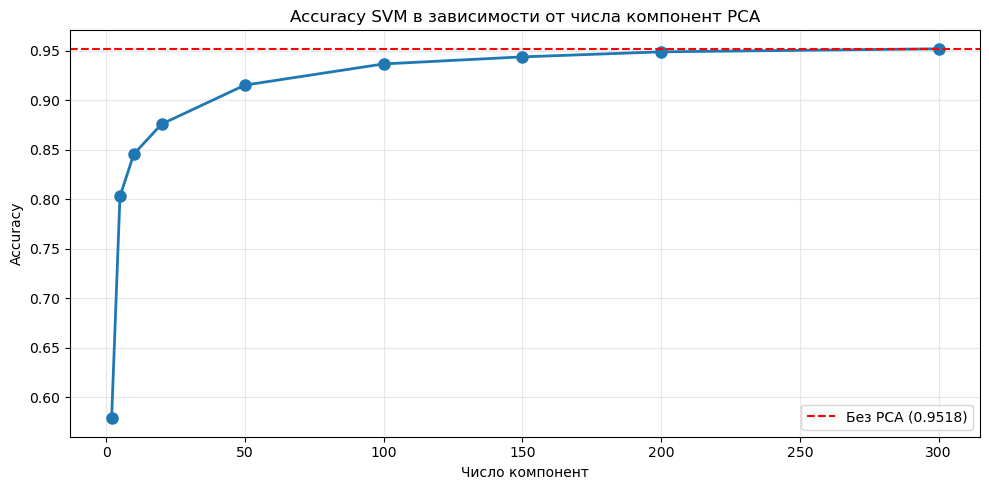

In [14]:
# подбор оптимального числа компонент
n_components_list = [2, 5, 10, 20, 50, 100, 150, 200, 300]
accuracies = []

for n in n_components_list:
    pca = PCA(n_components=n, random_state=42)
    X_tr = pca.fit_transform(X_train_sc)
    X_te = pca.transform(X_test_sc)
    svm = SVC(kernel='rbf', random_state=42)
    svm.fit(X_tr, y_train)
    acc = accuracy_score(y_test, svm.predict(X_te))
    accuracies.append(acc)
    print(f"n_components={n:>3d}, accuracy={acc:.4f}, дисперсия={pca.explained_variance_ratio_.sum():.4f}")

plt.figure(figsize=(10, 5))
plt.plot(n_components_list, accuracies, 'o-', linewidth=2, markersize=8)
plt.axhline(y=acc_full, color='red', linestyle='--', label=f'Без PCA ({acc_full:.4f})')
plt.xlabel('Число компонент')
plt.ylabel('Accuracy')
plt.title('Accuracy SVM в зависимости от числа компонент PCA')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Accuracy растёт с 0.5789 (2 компоненты) до 0.9518 (300 компонент, равно baseline без PCA). На 100 компонентах accuracy уже 0.9365 - потеря менее 2% при сжатии в 5.6 раз.

### Финальная модель с оптимальным числом компонент

In [15]:
# выбираем число компонент по порогу 95% дисперсии
pca_opt = PCA(n_components=0.95, random_state=42)
X_train_pca = pca_opt.fit_transform(X_train_sc)
X_test_pca = pca_opt.transform(X_test_sc)

n_opt = pca_opt.n_components_
var_opt = pca_opt.explained_variance_ratio_.sum()
print(f"Оптимальное число компонент (95% дисперсии): {n_opt}")
print(f"Объяснённая дисперсия: {var_opt:.4f}")
print(f"Сжатие: {X_train.shape[1]} -> {n_opt} признаков ({n_opt / X_train.shape[1]:.1%})")

# обучение SVM
svm_pca = SVC(kernel='rbf', random_state=42)
svm_pca.fit(X_train_pca, y_train)
y_pred_pca = svm_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)

print(f"\nSVM без PCA (561 признак): Accuracy = {acc_full:.4f}")
print(f"SVM с PCA ({n_opt} компонент):  Accuracy = {acc_pca:.4f}")
print(f"Разница: {acc_full - acc_pca:+.4f}")

Оптимальное число компонент (95% дисперсии): 102
Объяснённая дисперсия: 0.9508
Сжатие: 561 -> 102 признаков (18.2%)



SVM без PCA (561 признак): Accuracy = 0.9518
SVM с PCA (102 компонент):  Accuracy = 0.9376
Разница: +0.0143


### Confusion matrix

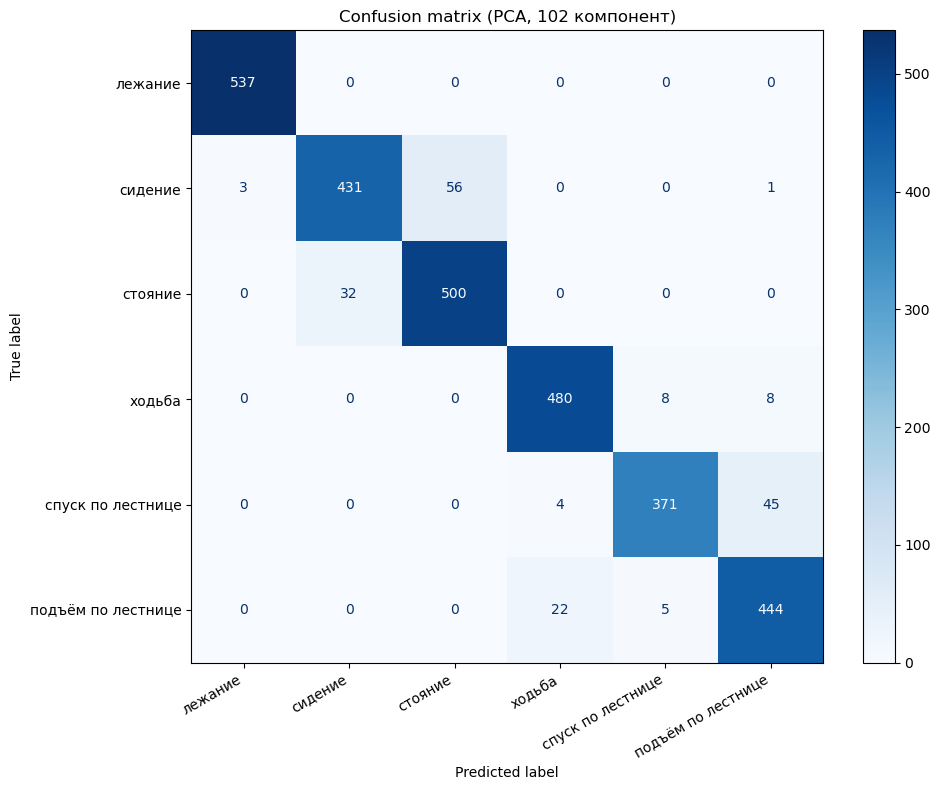

In [16]:
# confusion matrix для модели с PCA
cm = confusion_matrix(y_test, y_pred_pca)
labels_en = sorted(y_test.unique())
labels_ru = [activity_names_ru[l] for l in labels_en]

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_ru)
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title(f'Confusion matrix (PCA, {n_opt} компонент)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Основные ошибки - между сидением и стоянием (сидение: recall 0.88, стояние: recall 0.94). Лежание классифицируется почти идеально (F1=1.00). Динамические активности - F1 от 0.92 до 0.96.

In [17]:
# classification report
target_names = [activity_names_ru[l] for l in sorted(y_test.unique())]
print(classification_report(y_test, y_pred_pca, target_names=target_names))

                    precision    recall  f1-score   support

           лежание       0.99      1.00      1.00       537
           сидение       0.93      0.88      0.90       491
           стояние       0.90      0.94      0.92       532
            ходьба       0.95      0.97      0.96       496
 спуск по лестнице       0.97      0.88      0.92       420
подъём по лестнице       0.89      0.94      0.92       471

          accuracy                           0.94      2947
         macro avg       0.94      0.94      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



Лучший F1 у лежания (1.00) - уникальная ориентация датчиков. Худший F1 у сидения (0.90) и подъёма по лестнице (0.92). Общая accuracy=0.94 при сжатии 561 до 102 признаков (18.2%) - PCA сохраняет практически всю полезную информацию.

### Вклад исходных признаков в главные компоненты

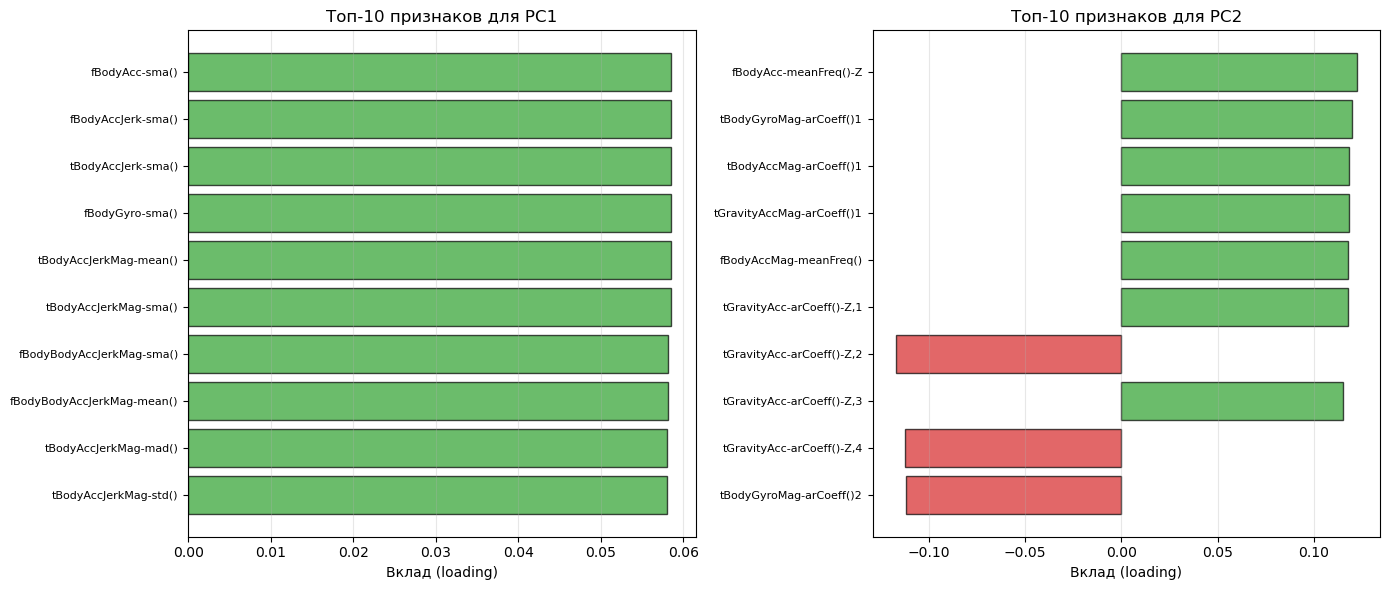

In [18]:
# топ-10 признаков по абсолютному вкладу в PC1 и PC2
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for idx, ax in enumerate(axes):
    loadings = pca_opt.components_[idx]
    top_idx = np.argsort(np.abs(loadings))[-10:][::-1]
    top_names = [feature_names[i] for i in top_idx]
    top_values = loadings[top_idx]

    colors = ['#d62728' if v < 0 else '#2ca02c' for v in top_values]
    ax.barh(range(len(top_names)), top_values, color=colors, edgecolor='black', alpha=0.7)
    ax.set_yticks(range(len(top_names)))
    ax.set_yticklabels(top_names, fontsize=8)
    ax.set_xlabel('Вклад (loading)')
    ax.set_title(f'Топ-10 признаков для PC{idx + 1}')
    ax.grid(True, alpha=0.3, axis='x')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

Первая главная компонента определяется в основном гравитационными и угловыми признаками - они разделяют статические и динамические активности. Вторая компонента выделяет другие характеристики движения.